# 🧪 03 — Uji Coba Model

Notebook ini digunakan untuk:
1. Verifikasi model bisa di-load dan berjalan
2. Uji prediksi dengan nilai manual (simulasi tanpa ESP32)
3. Validasi threshold klasifikasi lokal ESP32 vs KNN server
4. Analisis error: sampel yang salah klasifikasi
5. Learning curve — apakah perlu lebih banyak data?

**Prasyarat:** `models/knn_model.pkl` dan `models/scaler.pkl` sudah ada.

In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve, StratifiedKFold

from config import FEATURES, TARGET, CLASSES, CLASS_MAP, MODEL_PATH, SCALER_PATH
from utils  import load_and_clean_dataset, get_logger

logger = get_logger('notebook_03')
sns.set_theme(style='whitegrid')
print('Library siap.')

Library siap.


## 1. Load Model & Scaler

In [2]:
model  = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

print(f'✅  Model  : {MODEL_PATH}')
print(f'✅  Scaler : {SCALER_PATH}')
print(f'\nParameter model:')
print(f'  K          = {model.n_neighbors}')
print(f'  Metric     = {model.metric}')
print(f'  Weights    = {model.weights}')
print(f'  Training X = {model._fit_X.shape}')

✅  Model  : c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\knn_model.pkl
✅  Scaler : c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\scaler.pkl

Parameter model:
  K          = 15
  Metric     = euclidean
  Weights    = distance
  Training X = (143, 2)


## 2. Prediksi Manual — Simulasi Nilai Sensor

Masukkan nilai `accel_stddev` (g) dan `gyro_stddev` (°/s) secara manual untuk verifikasi.

| Aktivitas | accel_stddev (g) | gyro_stddev (°/s) |
|-----------|-----------------|------------------|
| Duduk     | ~0.01 – 0.04    | ~1 – 10          |
| Berjalan  | ~0.05 – 0.18    | ~15 – 60         |
| Berlari   | ~0.22 – 0.50+   | ~70 – 200+       |

In [3]:
def predict_activity(accel_std: float, gyro_std: float) -> dict:
    """
    Prediksi satu sampel menggunakan model KNN yang sudah dilatih.
    Kembalikan dict dengan kelas dan probabilitas.
    """
    X = np.array([[accel_std, gyro_std]])
    X_scaled = scaler.transform(X)
    pred     = model.predict(X_scaled)[0]
    proba    = model.predict_proba(X_scaled)[0]
    conf     = float(np.max(proba))
    return {
        'prediction' : pred,
        'confidence' : round(conf, 4),
        'probabilities': dict(zip(model.classes_, proba.round(4)))
    }

# ─── Ubah nilai di sini untuk simulasi ───────────────────
test_cases = [
    # (accel_std, gyro_std, expected_label)
    (0.010, 3.0,  'DUDUK'),
    (0.025, 8.0,  'DUDUK'),
    (0.060, 20.0, 'BERJALAN'),
    (0.130, 45.0, 'BERJALAN'),
    (0.250, 80.0, 'BERLARI'),
    (0.400, 150.0,'BERLARI'),
]

print(f'{"accel":>8} {"gyro":>8} {"expected":>12} {"predicted":>12} {"conf":>8} {"OK?":>5}')
print('─' * 60)
all_ok = True
for accel, gyro, expected in test_cases:
    result = predict_activity(accel, gyro)
    pred   = result['prediction']
    conf   = result['confidence']
    ok     = '✅' if pred == expected else '❌'
    if pred != expected:
        all_ok = False
    print(f'{accel:8.3f} {gyro:8.1f} {expected:>12} {pred:>12} {conf:8.3f} {ok}')

print('─' * 60)
if all_ok:
    print('✅  Semua test case benar!')
else:
    print('⚠️  Ada test case yang salah. Pertimbangkan re-training atau tuning threshold.')

   accel     gyro     expected    predicted     conf   OK?
────────────────────────────────────────────────────────────
   0.010      3.0        DUDUK        DUDUK    1.000 ✅
   0.025      8.0        DUDUK     BERJALAN    0.543 ❌
   0.060     20.0     BERJALAN     BERJALAN    0.947 ✅
   0.130     45.0     BERJALAN      BERLARI    0.882 ❌
   0.250     80.0      BERLARI      BERLARI    0.919 ✅
   0.400    150.0      BERLARI      BERLARI    0.867 ✅
────────────────────────────────────────────────────────────
⚠️  Ada test case yang salah. Pertimbangkan re-training atau tuning threshold.


## 3. Analisis Sampel yang Salah Klasifikasi

In [4]:
CLEAN_PATH = '../data/processed/dataset_clean.csv'
df = load_and_clean_dataset(CLEAN_PATH)

X      = df[FEATURES].values
y_true = df[TARGET].values

X_scaled = scaler.transform(X)
y_pred   = model.predict(X_scaled)

# Tambahkan kolom prediksi
df['predicted'] = y_pred
df['correct']   = df[TARGET] == df['predicted']

total     = len(df)
wrong     = (~df['correct']).sum()
acc_full  = df['correct'].mean()

print(f'Total sampel  : {total}')
print(f'Benar         : {total - wrong} ({acc_full*100:.2f}%)')
print(f'Salah         : {wrong} ({(1-acc_full)*100:.2f}%)')

if wrong > 0:
    print(f'\n=== Contoh sampel yang salah (maks 15) ===')
    display(
        df[~df['correct']][
            FEATURES + [TARGET, 'predicted']
        ].head(15)
    )

# Error per kelas
print('\n=== Error rate per kelas ===')
for cls in CLASSES:
    subset     = df[df[TARGET] == cls]
    err_rate   = 1 - subset['correct'].mean()
    print(f'  {cls:<10s}: {err_rate*100:.1f}% salah')

Total sampel  : 179
Benar         : 173 (96.65%)
Salah         : 6 (3.35%)

=== Contoh sampel yang salah (maks 15) ===


,accel_stddev,gyro_stddev,activity,predicted
7,0.010737,15.8778,DUDUK,BERJALAN
80,0.126967,42.3533,BERJALAN,BERLARI
88,0.111486,30.4449,BERJALAN,BERLARI
110,0.132956,27.6016,BERJALAN,BERLARI
154,0.126262,35.5155,BERLARI,BERJALAN
159,0.115384,33.0090,BERLARI,BERJALAN



=== Error rate per kelas ===
  DUDUK     : 1.7% salah
  BERJALAN  : 5.0% salah
  BERLARI   : 3.4% salah


## 4. Visualisasi Sampel Benar vs Salah

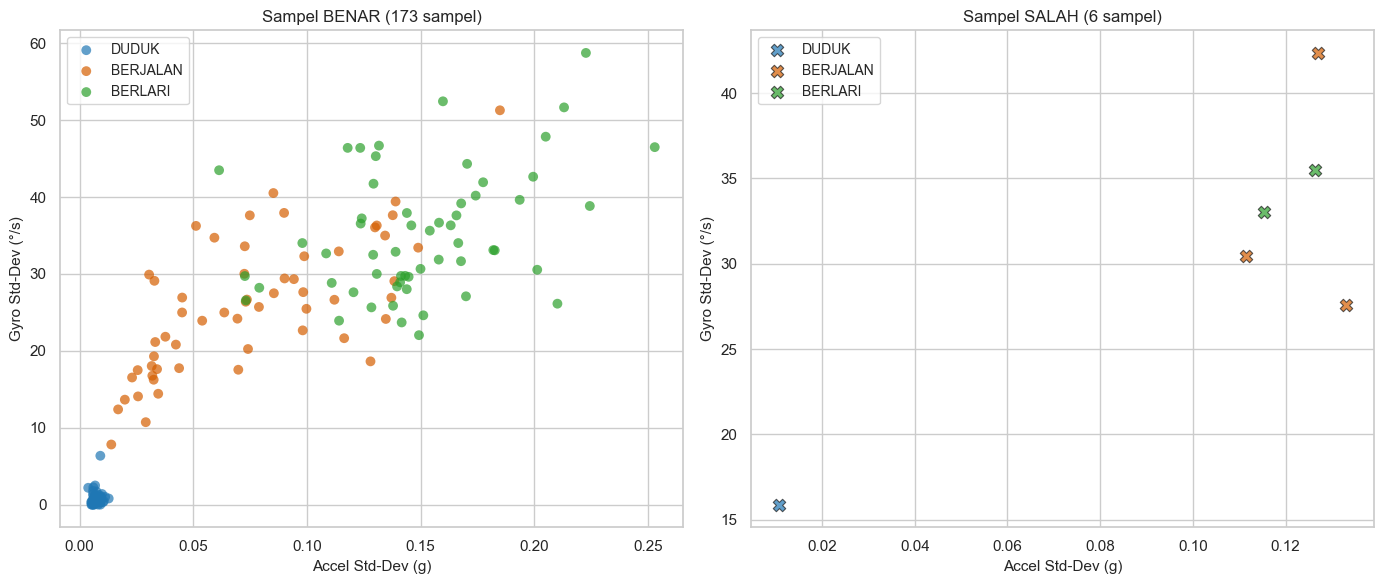

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_cls = {'DUDUK': '#1F77B4', 'BERJALAN': '#D55E00', 'BERLARI': '#2CA02C'}

for i, (ax, title, subset) in enumerate([
    (axes[0], 'Sampel BENAR', df[df['correct']]),
    (axes[1], 'Sampel SALAH', df[~df['correct']])
]):
    for cls in CLASSES:
        s = subset[subset[TARGET] == cls]
        ax.scatter(
            s['accel_stddev'], s['gyro_stddev'],
            c=colors_cls[cls], label=cls,
            alpha=0.7, edgecolors='k' if i == 1 else 'none',
            linewidth=0.8, s=50 if i == 0 else 80,
            marker='o' if i == 0 else 'X'
        )
    ax.set_xlabel('Accel Std-Dev (g)', fontsize=11)
    ax.set_ylabel('Gyro Std-Dev (°/s)', fontsize=11)
    ax.set_title(f'{title} ({len(subset)} sampel)', fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/error_analysis.png', dpi=150)
plt.show()

## 5. Learning Curve — Apakah Perlu Lebih Banyak Data?

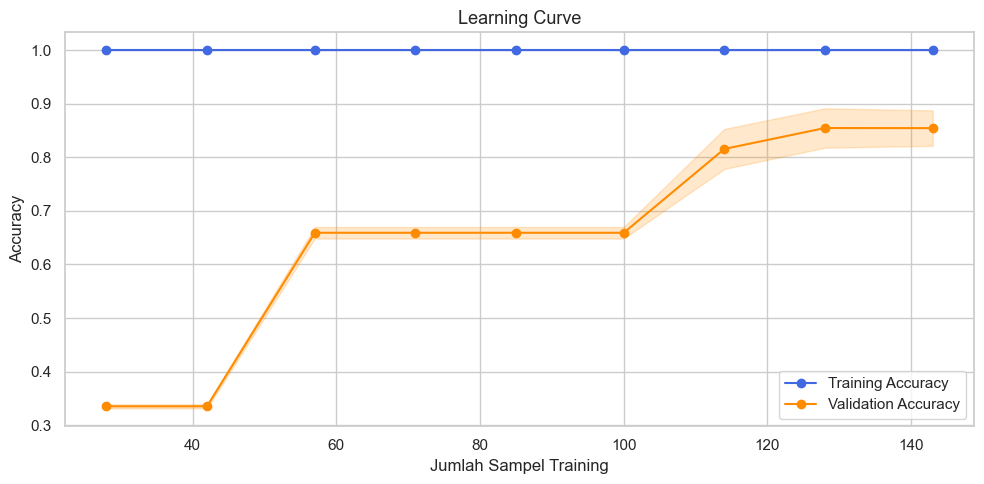

Gap train-val terakhir: 14.54%
⚠️  Overfitting terdeteksi. Coba tambah data atau kurangi K.


In [6]:
from sklearn.model_selection import learning_curve

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    model, X_scaled, y_true,
    cv=kfold,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue',  label='Training Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='royalblue')
plt.plot(train_sizes, val_mean,   'o-', color='darkorange', label='Validation Accuracy')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='darkorange')

plt.xlabel('Jumlah Sampel Training', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Learning Curve', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/processed/learning_curve.png', dpi=150)
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'Gap train-val terakhir: {gap*100:.2f}%')
if gap > 0.10:
    print('⚠️  Overfitting terdeteksi. Coba tambah data atau kurangi K.')
elif val_mean[-1] < 0.85:
    print('⚠️  Akurasi validasi masih rendah. Coba tambah data training.')
else:
    print('✅  Model terlihat generalize dengan baik.')

## 6. Validasi Threshold ESP32 vs KNN Server

Bandingkan hasil klasifikasi lokal ESP32 (berdasarkan threshold) vs hasil KNN server.

In [7]:
# Threshold dari ESP32 (sinkronkan dengan nilai di file .ino)
THR_SIT_ACCEL = 0.040
THR_RUN_ACCEL = 0.220
THR_SIT_GYRO  = 12.0
THR_RUN_GYRO  = 65.0

def esp32_classify(accel_std, gyro_std):
    """Simulasi logika klasifikasi lokal ESP32."""
    if   accel_std < THR_SIT_ACCEL:  accel_vote = 'DUDUK'
    elif accel_std >= THR_RUN_ACCEL: accel_vote = 'BERLARI'
    else:                            accel_vote = 'BERJALAN'

    if   gyro_std < THR_SIT_GYRO:   gyro_vote  = 'DUDUK'
    elif gyro_std >= THR_RUN_GYRO:  gyro_vote  = 'BERLARI'
    else:                           gyro_vote  = 'BERJALAN'

    if accel_vote == gyro_vote:
        return accel_vote
    elif 'BERLARI' in [accel_vote, gyro_vote]:
        if set([accel_vote, gyro_vote]) == {'BERLARI', 'BERJALAN'}:
            return 'BERJALAN'
        return 'BERLARI'
    else:
        return 'BERJALAN'

df['esp32_pred'] = df.apply(
    lambda r: esp32_classify(r['accel_stddev'], r['gyro_stddev']), axis=1
)

# Bandingkan
esp32_acc = accuracy_score(df[TARGET], df['esp32_pred'])
knn_acc   = accuracy_score(df[TARGET], df['predicted'])

print(f'Akurasi klasifikasi lokal ESP32 : {esp32_acc*100:.2f}%')
print(f'Akurasi KNN Server              : {knn_acc*100:.2f}%')

diff = knn_acc - esp32_acc
print(f'\nKNN unggul {diff*100:+.2f}% dibanding ESP32 lokal.')
if diff < 0.03:
    print('💡  Perbedaan kecil — threshold ESP32 sudah cukup baik!')
else:
    print('💡  KNN server memberikan manfaat signifikan atas klasifikasi lokal.')

Akurasi klasifikasi lokal ESP32 : 65.36%
Akurasi KNN Server              : 96.65%

KNN unggul +31.28% dibanding ESP32 lokal.
💡  KNN server memberikan manfaat signifikan atas klasifikasi lokal.


## 7. Ringkasan Akhir

In [8]:
print('=' * 55)
print('  RINGKASAN UJI COBA MODEL')
print('=' * 55)
print(f'  Algoritma      : KNN (K={model.n_neighbors}, metric={model.metric})')
print(f'  Fitur          : {FEATURES}')
print(f'  Kelas          : {CLASSES}')
print(f'  Total dataset  : {len(df)}')
print(f'  Akurasi KNN    : {knn_acc*100:.2f}%')
print(f'  Akurasi ESP32  : {esp32_acc*100:.2f}%')
print('=' * 55)
print()
print('File yang dihasilkan:')
for f in [
    'data/processed/error_analysis.png',
    'data/processed/learning_curve.png',
]:
    print(f'  → {f}')

  RINGKASAN UJI COBA MODEL
  Algoritma      : KNN (K=15, metric=euclidean)
  Fitur          : ['accel_stddev', 'gyro_stddev']
  Kelas          : ['DUDUK', 'BERJALAN', 'BERLARI']
  Total dataset  : 179
  Akurasi KNN    : 96.65%
  Akurasi ESP32  : 65.36%

File yang dihasilkan:
  → data/processed/error_analysis.png
  → data/processed/learning_curve.png
